# PBDEs model based target - time series

In [1]:
from matplotlib.path import Path as mPath
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Point, Polygon
from shapely.plotting import plot_polygon
import xarray as xr

from scipy.optimize import curve_fit

In [2]:
file_year1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_1.nc'
file_year2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_2.nc'
file_year3 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_3.nc'
file_year4 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_4.nc'
file_year5 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_5.nc'
file_year6 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_6.nc'
file_year7 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_7.nc'
file_year8 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_8.nc'
file_year9 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_9.nc'
file_year10 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_10.nc'
file_year11 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_11.nc'
file_year12 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_12.nc'

In [3]:
max_year = 2050

In [4]:
output = pd.read_excel('/ocean/vvalenzuela/MOAD/analysis-vicente/Ocean_Parcels/PBDE_simulations/Data_BDE_99_Min_Best_Max.xlsx') 

In [6]:
output['Unnamed: 0']

0       1970-01-01
1       1970-01-02
2       1970-01-03
3       1970-01-04
4       1970-01-05
           ...    
29580   2050-12-27
29581   2050-12-28
29582   2050-12-29
29583   2050-12-30
29584   2050-12-31
Name: Unnamed: 0, Length: 29585, dtype: datetime64[ns]

In [5]:
BDE_99 = pd.DataFrame({
    'Date': output['Unnamed: 0'],
    'Min': output['Min'],
    'Best': output['Best'],
    'Max': output['Max']
})

In [6]:
BDE_99['year'] = BDE_99['Date'].dt.year
discharge_min = BDE_99.groupby('year')['Min'].mean()
discharge_best = BDE_99.groupby('year')['Best'].mean()
discharge_max = BDE_99.groupby('year')['Max'].mean()

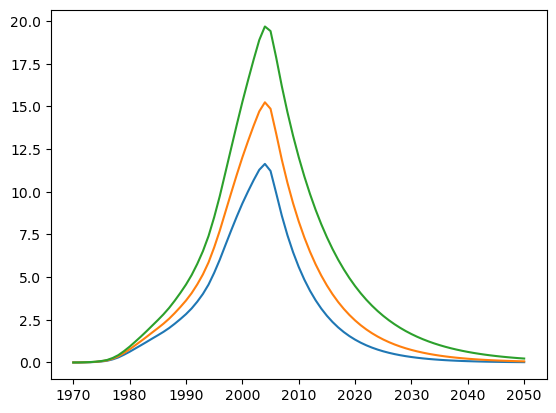

In [7]:
plt.plot(discharge_min)
plt.plot(discharge_best)
plt.plot(discharge_max)

In [8]:
year1 = xr.open_dataset(file_year1)
year2 = xr.open_dataset(file_year2)
year3 = xr.open_dataset(file_year3)
year4 = xr.open_dataset(file_year4)
year5 = xr.open_dataset(file_year5)
year6 = xr.open_dataset(file_year6)
year7 = xr.open_dataset(file_year7)
year8 = xr.open_dataset(file_year8)
year9 = xr.open_dataset(file_year9)
year10 = xr.open_dataset(file_year10)
year11 = xr.open_dataset(file_year11)
year12 = xr.open_dataset(file_year12)

In [9]:
def pad_year(year, conversion, ts_full_yr1):
    ts_full_yeard = (year.status == 2).sum(axis=0) * conversion
    ts_full_year = np.zeros_like(ts_full_yr1)
    ts_full_year[1::2] = ts_full_yeard
    ts_full_year[0] = 0.5 * (ts_full_year[1] + ts_full_year[-1])
    ts_full_year[2::2] = 0.5 * (ts_full_year[1:-2:2] + ts_full_year[3::2])
    return ts_full_year

In [10]:
conversion = 1 / 96 / 1000# 1 g per day = 96 particles, change to kg,
ts_full_yr1 = (year1.status == 2).sum(axis=0) * conversion
ts_full_yr2 = (year2.status == 2).sum(axis=0) * conversion
ts_full_yr3 = pad_year(year3, conversion, ts_full_yr1)
ts_full_yr4 = pad_year(year4, conversion, ts_full_yr1)
ts_full_yr5 = pad_year(year5, conversion, ts_full_yr1)
ts_full_yr6 = pad_year(year6, conversion, ts_full_yr1)
ts_full_yr7 = pad_year(year7, conversion, ts_full_yr1)
ts_full_yr8 = pad_year(year8, conversion, ts_full_yr1)
ts_full_yr9 = pad_year(year9, conversion, ts_full_yr1)
ts_full_yr10 = pad_year(year10, conversion, ts_full_yr1)
ts_full_yr11 = pad_year(year11, conversion, ts_full_yr1)
ts_full_yr12 = pad_year(year12, conversion, ts_full_yr1)

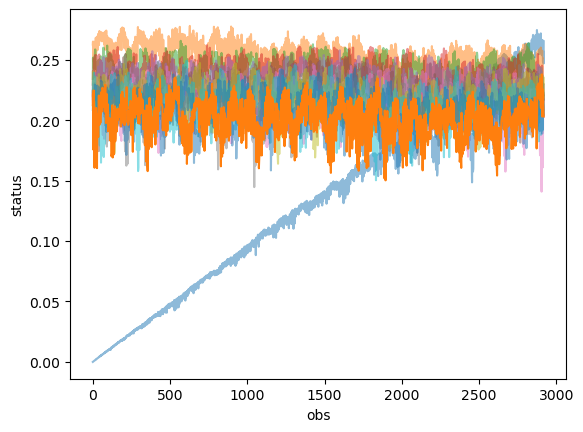

In [11]:
fig, ax = plt.subplots(1, 1)
ts_full_yr1.plot(ax=ax, alpha=0.5);
ts_full_yr2.plot(ax=ax, alpha=0.5);
ax.plot(ts_full_yr3, alpha=0.5);
ax.plot(ts_full_yr4, alpha=0.5);
ax.plot(ts_full_yr5, alpha=0.5);
ax.plot(ts_full_yr6, alpha=0.5);
ax.plot(ts_full_yr7, alpha=0.5);
ax.plot(ts_full_yr8, alpha=0.5);
ax.plot(ts_full_yr9, alpha = .5);
ax.plot(ts_full_yr10, alpha = .5);
ax.plot(ts_full_yr11, alpha = .5);
ax.plot(ts_full_yr12);


In [12]:
one_year = 365 * 8
zero_values = np.zeros((max_year-1970+1)*one_year)
one_values = np.zeros_like(zero_values)
two_values = np.zeros_like(zero_values)
three_values = np.zeros_like(zero_values)
four_values = np.zeros_like(zero_values)
five_values = np.zeros_like(zero_values)
six_values = np.zeros_like(zero_values)
seven_values = np.zeros_like(zero_values)
eight_values = np.zeros_like(zero_values)
nine_values = np.zeros_like(zero_values)
ten_values = np.zeros_like(zero_values)
eleven_values = np.zeros_like(zero_values)

for year in range(1970, max_year):
    zero_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        discharge_max[year] * ts_full_yr1)
for year in range(1971, max_year):
    one_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        zero_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-1] * ts_full_yr2)
for year in range(1972, max_year):
    two_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        one_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-2] * ts_full_yr3)
for year in range(1973, max_year):
    three_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        two_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-3] * ts_full_yr4)
for year in range(1974, max_year):
    four_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        three_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-4] * ts_full_yr5)
for year in range(1975, max_year):
    five_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        four_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-5] * ts_full_yr6)
for year in range(1976, max_year):
    six_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        five_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-6] * ts_full_yr7)
for year in range(1977, max_year):
    seven_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        six_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-7] * ts_full_yr8)
for year in range(1978, max_year):
    eight_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        seven_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-8] * ts_full_yr9)    
for year in range(1979, max_year):
    nine_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        eight_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-9] * ts_full_yr10)
for year in range(1980, max_year):
    ten_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        nine_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-10] * ts_full_yr11)           
for year in range(1981, max_year):
    eleven_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        ten_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-11] * ts_full_yr12)     

/home/vvalenzuela/conda_envs/Parcels/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/vvalenzuela/conda_envs/Parcels/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


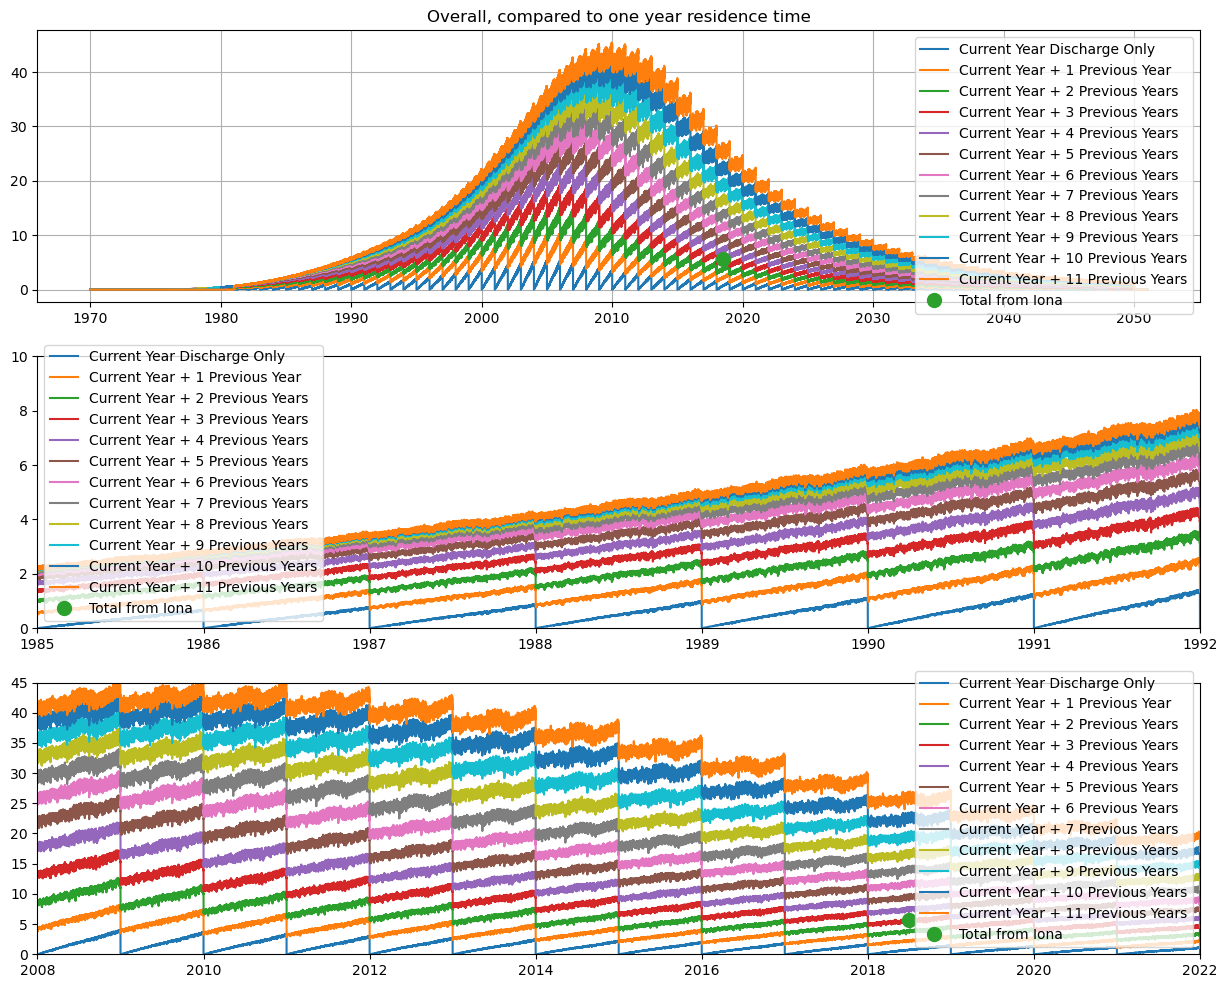

In [15]:
fig, axs = plt.subplots(3, 1, figsize=(15, 12))
for ax in axs:
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), zero_values, label="Current Year Discharge Only");
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), one_values, label="Current Year + 1 Previous Year");
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), two_values, label="Current Year + 2 Previous Years");
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), three_values, label="Current Year + 3 Previous Years")
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), four_values, label="Current Year + 4 Previous Years")
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), five_values, label="Current Year + 5 Previous Years")
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), six_values, label="Current Year + 6 Previous Years")
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), seven_values, label="Current Year + 7 Previous Years")
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), eight_values, label="Current Year + 8 Previous Years")
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), nine_values, label="Current Year + 9 Previous Years")
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), ten_values, label="Current Year + 10 Previous Years")
    ax.plot(np.arange(1970, max_year+1, 1/(8*365)), eleven_values, label="Current Year + 11 Previous Years")

    ax.plot([2018.5], [71/2.5/5], 'o', markersize=10, label='Total from Iona'); # 2.5 proportion from Iona, 1/5 part from PBDE-99?
    ax.legend();
axs[1].set_xlim(1985, 1992);
axs[1].set_ylim(0, 10);
axs[2].set_xlim(2008, 2022);
axs[2].set_ylim(0, 45);

axs[0].grid();
axs[0].set_title('Overall, compared to one year residence time');

# Southern Strait - Station S4-1.5

In [16]:
from matplotlib.path import Path

path = {'coords' : '/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc',
'mask' : '/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc',
'bathy' : '/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc'
}
#
coords = xr.open_dataset(path['coords'], decode_times=False)
mask = xr.open_dataset(path['mask'])
bathy = xr.open_dataset(path['bathy'])

In [17]:
def get_total_timeseries_optimized(filename, polygon_coords, 
                                  lon_var='lon', lat_var='lat', status_var='status', 
                                  target_status=2, chunk_size=500):
    """
    Computes a particle timeseries filtered by status and polygon containment.
    Optimized for minimal memory usage and high execution speed via chunking.
    """
    poly_path = Path(polygon_coords)
    
    with xr.open_dataset(filename) as data:
        n_obs = data.sizes['obs'] 
        counts_per_time = np.zeros(n_obs, dtype=int)
        
        for start in range(0, n_obs, chunk_size):
            end = min(start + chunk_size, n_obs)
            
            status_chunk = data[status_var].isel(obs=slice(start, end)).values
            
            if isinstance(target_status, (list, tuple, np.ndarray)):
                status_mask = np.isin(status_chunk, target_status)
            else:
                status_mask = (status_chunk == target_status)
            
            if not np.any(status_mask):
                continue
                

            lon_chunk = data[lon_var].isel(obs=slice(start, end)).values[status_mask]
            lat_chunk = data[lat_var].isel(obs=slice(start, end)).values[status_mask]
            
            points = np.column_stack((lon_chunk, lat_chunk))
            inside_poly = poly_path.contains_points(points)
            
            if np.any(inside_poly):

                chunk_time_indices = np.where(status_mask)[1]
                absolute_time_indices = chunk_time_indices[inside_poly] + start
                
                counts_per_time += np.bincount(absolute_time_indices, minlength=n_obs)
                
    return pd.DataFrame({'Total_Count': counts_per_time})

In [18]:
from Regions_functions_V2 import polygon_S1, polygon_lon_lat_S1

In [19]:
volume_S1 = 109.140915985 * 1e9

In [20]:
tseries_y1 = get_total_timeseries_optimized(file_year1, polygon_lon_lat_S1)['Total_Count'].values[::2]
tseries_y2 = get_total_timeseries_optimized(file_year2, polygon_lon_lat_S1)['Total_Count'].values[::2]
tseries_y3 = get_total_timeseries_optimized(file_year3, polygon_lon_lat_S1)['Total_Count'].values
tseries_y4 = get_total_timeseries_optimized(file_year4, polygon_lon_lat_S1)['Total_Count'].values
tseries_y5 = get_total_timeseries_optimized(file_year5, polygon_lon_lat_S1)['Total_Count'].values
tseries_y6 = get_total_timeseries_optimized(file_year6, polygon_lon_lat_S1)['Total_Count'].values
tseries_y7 = get_total_timeseries_optimized(file_year7, polygon_lon_lat_S1)['Total_Count'].values
tseries_y8 = get_total_timeseries_optimized(file_year8, polygon_lon_lat_S1)['Total_Count'].values
tseries_y9 = get_total_timeseries_optimized(file_year9, polygon_lon_lat_S1)['Total_Count'].values
tseries_y10 = get_total_timeseries_optimized(file_year10, polygon_lon_lat_S1)['Total_Count'].values
tseries_y11 = get_total_timeseries_optimized(file_year11, polygon_lon_lat_S1)['Total_Count'].values
tseries_y12 = get_total_timeseries_optimized(file_year12, polygon_lon_lat_S1)['Total_Count'].values

In [21]:
one_year = 365 * 4
zero_values_max = np.zeros((max_year-1970+1)*one_year)
one_values_max = np.zeros_like(zero_values_max)
two_values_max = np.zeros_like(zero_values_max)
three_values_max = np.zeros_like(zero_values_max)
four_values_max = np.zeros_like(zero_values_max)
five_values_max = np.zeros_like(zero_values_max)
six_values_max = np.zeros_like(zero_values_max)
seven_values_max = np.zeros_like(zero_values_max)
eight_values_max = np.zeros_like(zero_values_max)
nine_values_max = np.zeros_like(zero_values_max)
ten_values_max = np.zeros_like(zero_values_max)
eleven_values_max = np.zeros_like(zero_values_max)

for year in range(1970, max_year):
    zero_values_max[(year-1970)*one_year:(year-1970+1)*one_year] = (
        discharge_max[year] * tseries_y1 * conversion / volume_S1)
for year in range(1971, max_year):
    one_values_max[(year-1970)*one_year:(year-1970+1)*one_year] = (
        zero_values_max[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-1] * tseries_y2 * conversion / volume_S1)
for year in range(1972, max_year):
    two_values_max[(year-1970)*one_year:(year-1970+1)*one_year] = (
        one_values_max[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-2] * tseries_y3 * conversion / volume_S1)
for year in range(1973, max_year):
    three_values_max[(year-1970)*one_year:(year-1970+1)*one_year] = (
        two_values_max[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-3] * tseries_y4 * conversion / volume_S1)
for year in range(1974, max_year):
    four_values_max[(year-1970)*one_year:(year-1970+1)*one_year] = (
        three_values_max[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-4] * tseries_y5 * conversion / volume_S1)
for year in range(1975, max_year):
    five_values_max[(year-1970)*one_year:(year-1970+1)*one_year] = (
        four_values_max[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-5] * tseries_y6 * conversion / volume_S1)
for year in range(1976, max_year):
    six_values_max[(year-1970)*one_year:(year-1970+1)*one_year] = (
        five_values_max[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-6] * tseries_y7 * conversion / volume_S1)
for year in range(1977, max_year):
    seven_values_max[(year-1970)*one_year:(year-1970+1)*one_year] = (
        six_values_max[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-7] * tseries_y8 * conversion / volume_S1)
for year in range(1978, max_year):
    eight_values_max[(year-1970)*one_year:(year-1970+1)*one_year] = (
        seven_values_max[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-8] * tseries_y9 * conversion / volume_S1)
for year in range(1979, max_year):
    nine_values_max[(year-1970)*one_year:(year-1970+1)*one_year] = (
        eight_values_max[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-9] * tseries_y10 * conversion / volume_S1)    
for year in range(1980, max_year):
    ten_values_max[(year-1970)*one_year:(year-1970+1)*one_year] = (
        nine_values_max[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-10] * tseries_y11 * conversion / volume_S1) 
for year in range(1981, max_year):
    eleven_values_max[(year-1970)*one_year:(year-1970+1)*one_year] = (
        ten_values_max[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_max[year-11] * tseries_y12 * conversion / volume_S1)              

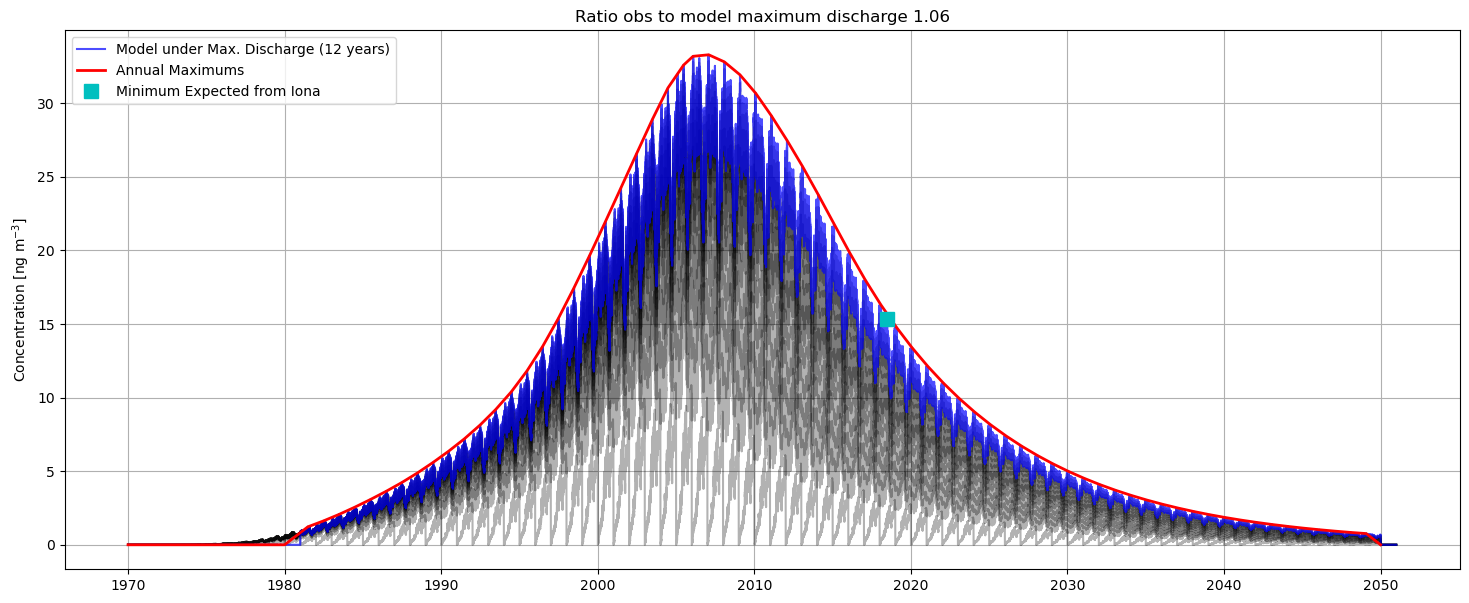

In [22]:
max_arrays = [zero_values_max, one_values_max, two_values_max, three_values_max, four_values_max, five_values_max, 
              six_values_max, seven_values_max, eight_values_max, nine_values_max, ten_values_max, eleven_values_max]

fig, ax = plt.subplots(figsize=(18, 7))
time_array = np.arange(1970, max_year+1, 1/(4*365))

for i in range(0, 11):
    ax.plot(time_array, max_arrays[i]*1e12, 'k', alpha=.3)

ax.plot(time_array, eleven_values_max*1e12, 'b', alpha = .7, label='Model under Max. Discharge (12 years)')

points_per_year = 4 * 365
x_peaks = []
y_peaks = []

for year in range(1970, max_year+1):
    start_idx = (year - 1970) * points_per_year
    end_idx = (year - 1970 + 1) * points_per_year
    
    year_data = (eleven_values_max * 1e12)[start_idx:end_idx]
    
    if len(year_data) > 0:
        max_val = np.max(year_data)
        max_idx = start_idx + np.argmax(year_data)
        max_time = time_array[max_idx]
        
        x_peaks.append(max_time)
        y_peaks.append(max_val)

ax.plot(x_peaks, y_peaks, 'r', linewidth=2, label='Annual Maximums')

ax.plot([2018.5], [(70.2-31.9)/2.5], 'sc', markersize=10, label='Minimum Expected from Iona')

ax.set_ylabel('Concentration [ng m$^{-3}$]')
ax.legend(loc='upper left')

ratio_val = eleven_values_max[(2018-1970)*4*365:(2019-1970)*4*365].max()*1e12/((70.2-31.9)/2.5)
ax.set_title(f'Ratio obs to model maximum discharge {ratio_val:.2f}')
ax.grid()

plt.show()

In [23]:
one_year = 365 * 4
zero_values_min = np.zeros((max_year-1970+1)*one_year)
one_values_min = np.zeros_like(zero_values_min)
two_values_min = np.zeros_like(zero_values_min)
three_values_min = np.zeros_like(zero_values_min)
four_values_min = np.zeros_like(zero_values_min)
five_values_min = np.zeros_like(zero_values_min)
six_values_min = np.zeros_like(zero_values_min)
seven_values_min = np.zeros_like(zero_values_min)
eight_values_min = np.zeros_like(zero_values_min)
nine_values_min = np.zeros_like(zero_values_min)
ten_values_min = np.zeros_like(zero_values_min)
eleven_values_min = np.zeros_like(zero_values_min)

for year in range(1970, max_year):
    zero_values_min[(year-1970)*one_year:(year-1970+1)*one_year] = (
        discharge_min[year] * tseries_y1 * conversion / volume_S1)
for year in range(1971, max_year):
    one_values_min[(year-1970)*one_year:(year-1970+1)*one_year] = (
        zero_values_min[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_min[year-1] * tseries_y2 * conversion / volume_S1)
for year in range(1972, max_year):
    two_values_min[(year-1970)*one_year:(year-1970+1)*one_year] = (
        one_values_min[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_min[year-2] * tseries_y3 * conversion / volume_S1)
for year in range(1973, max_year):
    three_values_min[(year-1970)*one_year:(year-1970+1)*one_year] = (
        two_values_min[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_min[year-3] * tseries_y4 * conversion / volume_S1)
for year in range(1974, max_year):
    four_values_min[(year-1970)*one_year:(year-1970+1)*one_year] = (
        three_values_min[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_min[year-4] * tseries_y5 * conversion / volume_S1)
for year in range(1975, max_year):
    five_values_min[(year-1970)*one_year:(year-1970+1)*one_year] = (
        four_values_min[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_min[year-5] * tseries_y6 * conversion / volume_S1)
for year in range(1976, max_year):
    six_values_min[(year-1970)*one_year:(year-1970+1)*one_year] = (
        five_values_min[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_min[year-6] * tseries_y7 * conversion / volume_S1)
for year in range(1977, max_year):
    seven_values_min[(year-1970)*one_year:(year-1970+1)*one_year] = (
        six_values_min[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_min[year-7] * tseries_y8 * conversion / volume_S1)
for year in range(1978, max_year):
    eight_values_min[(year-1970)*one_year:(year-1970+1)*one_year] = (
        seven_values_min[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_min[year-8] * tseries_y9 * conversion / volume_S1)
for year in range(1979, max_year):
    nine_values_min[(year-1970)*one_year:(year-1970+1)*one_year] = (
        eight_values_min[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_min[year-9] * tseries_y10 * conversion / volume_S1)    
for year in range(1980, max_year):
    ten_values_min[(year-1970)*one_year:(year-1970+1)*one_year] = (
        nine_values_min[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_min[year-10] * tseries_y11 * conversion / volume_S1)
for year in range(1981, max_year):
    eleven_values_min[(year-1970)*one_year:(year-1970+1)*one_year] = (
        ten_values_min[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge_min[year-11] * tseries_y12 * conversion / volume_S1)             

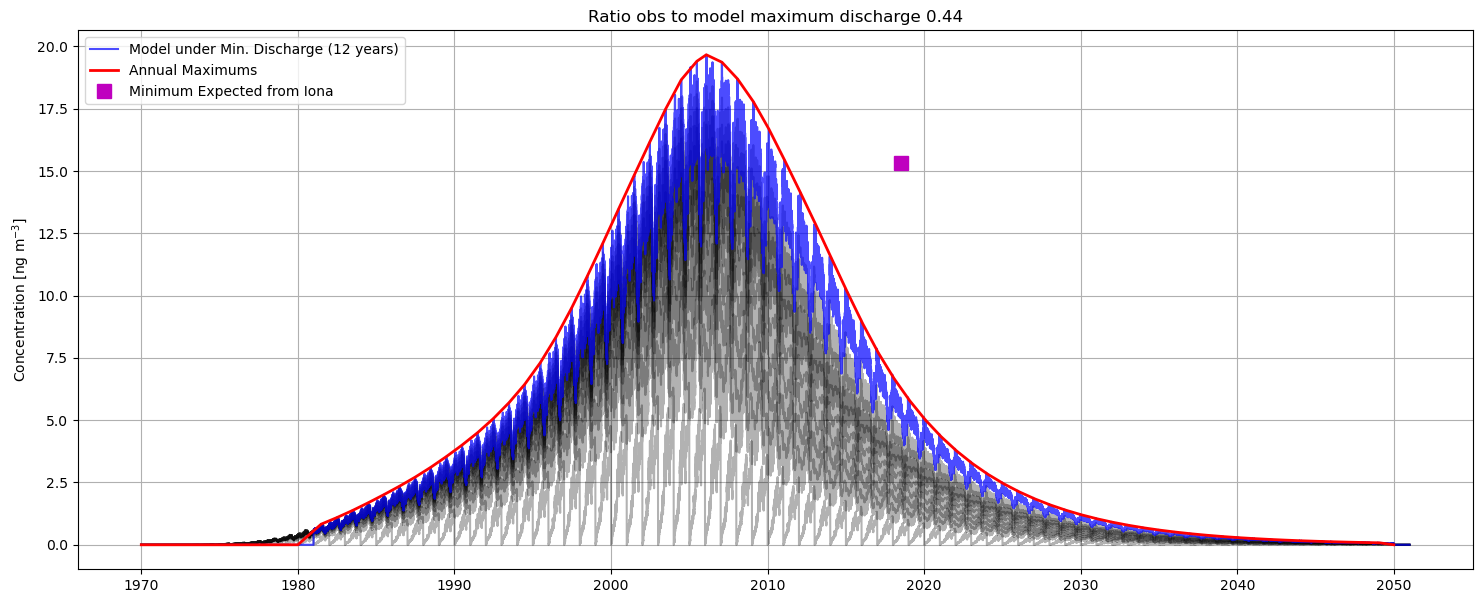

In [24]:
min_arrays = [zero_values_min, one_values_min, two_values_min, three_values_min, four_values_min, 
              five_values_min, six_values_min, seven_values_min, eight_values_min, nine_values_min, ten_values_min, eleven_values_min]

fig, ax = plt.subplots(figsize=(18, 7))
time_array = np.arange(1970, max_year+1, 1/(4*365))

for i in range(0, 9):
    ax.plot(time_array, min_arrays[i]*1e12, 'k', alpha=.3)

ax.plot(time_array, eleven_values_min*1e12, 'b', alpha = .7, label='Model under Min. Discharge (12 years)')

points_per_year = 4 * 365
x_peaks = []
y_peaks = []

for year in range(1970, max_year+1):
    start_idx = (year - 1970) * points_per_year
    end_idx = (year - 1970 + 1) * points_per_year
    
    year_data = (eleven_values_min * 1e12)[start_idx:end_idx]
    
    if len(year_data) > 0:
        max_val = np.max(year_data)
        max_idx = start_idx + np.argmax(year_data)
        max_time = time_array[max_idx]
        
        x_peaks.append(max_time)
        y_peaks.append(max_val)

ax.plot(x_peaks, y_peaks, 'r', linewidth=2, label='Annual Maximums')

ax.plot([2018.5], [(70.2-31.9)/2.5], 'sm', markersize=10, label='Minimum Expected from Iona')

ax.set_ylabel('Concentration [ng m$^{-3}$]')
ax.legend(loc='upper left')

ratio_val = eleven_values_min[(2018-1970)*4*365:(2019-1970)*4*365].max()*1e12/((70.2-31.9)/2.5)
ax.set_title(f'Ratio obs to model maximum discharge {ratio_val:.2f}')
ax.grid()

plt.show()